In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
df=pd.read_csv('data/cardekho_imputated.csv')
df.sample(10)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
8783,11303,Kia Seltos,Kia,Seltos,2,6076,Dealer,Petrol,Manual,16.80,1497,113.40,5,1149000
11533,14637,Hyundai Venue,Hyundai,Venue,1,10000,Dealer,Diesel,Manual,23.70,1396,88.70,5,1039000
2103,2693,Ford Ecosport,Ford,Ecosport,6,71893,Dealer,Diesel,Manual,21.70,1498,98.96,5,611000
3064,3889,Renault KWID,Renault,KWID,2,5000,Individual,Petrol,Manual,25.17,799,53.30,5,350000
13230,16790,Hyundai Santro,Hyundai,Santro,8,76945,Dealer,Petrol,Manual,17.92,1086,62.10,5,350000
14044,17813,Tata Hexa,Tata,Hexa,3,44000,Dealer,Diesel,Automatic,17.60,2179,153.86,7,1400000
198,262,Renault KWID,Renault,KWID,1,6000,Individual,Petrol,Manual,22.30,799,53.26,5,450000
9292,11932,Hyundai i20,Hyundai,i20,10,60000,Dealer,Petrol,Manual,17.00,1197,80.00,5,265000
11017,14002,BMW 5,BMW,5,13,70000,Individual,Diesel,Automatic,16.73,2495,218.00,5,550000
12016,15244,Maruti Swift,Maruti,Swift,6,82000,Dealer,Diesel,Manual,28.40,1248,74.00,5,555000


In [26]:
df.shape

(15411, 14)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [28]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [29]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [30]:
df.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

In [31]:
df.drop('car_name',axis=1,inplace=True)
df.drop('model',axis=1,inplace=True)

In [32]:
df.columns

Index(['Unnamed: 0', 'brand', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

<Axes: xlabel='selling_price', ylabel='Count'>

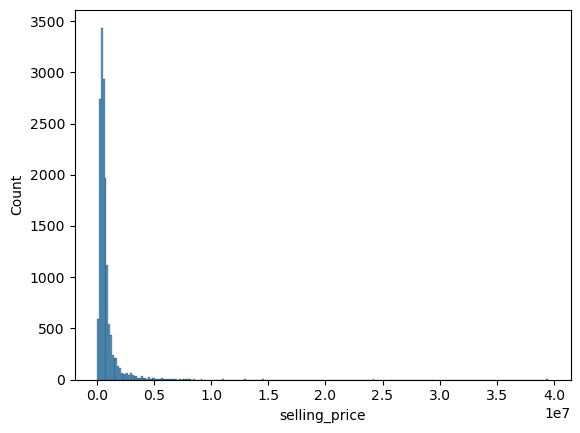

In [33]:
sns.histplot(df['selling_price'])

In [34]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Numerical Features : 8
Num of Categorical Features : 4
Num of Discrete Features : 2
Num of Continuous Features : 6


In [35]:
X = df.drop(['selling_price'], axis=1)
y = df['selling_price']

In [36]:
X = pd.get_dummies(X, columns=['brand', 'seller_type', 'fuel_type', 'transmission_type'], drop_first=True)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [38]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.9281845479738172
MAE: 99261.29257216996
RMSE: 232510.99879496213


In [39]:
import numpy as np

y_log = np.log1p(y)   # log1p = log(1 + y), safely handles the range

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

In [40]:
rf_log = RandomForestRegressor(random_state=42)
rf_log.fit(X_train, y_train_log)

y_pred_log = rf_log.predict(X_test)

In [41]:
y_pred_actual = np.expm1(y_pred_log)      # reverse the log1p
y_test_actual = np.expm1(y_test_log)

print("R²:", r2_score(y_test_actual, y_pred_actual))
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

R²: 0.9299224394659379
MAE: 97908.04409371054
RMSE: 229680.4551796403
